# ACTIVIDAD 2 - MASTER AI - VISION

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# LOAD AND CONVERT TO RGB

img_front = cv2.imread('../../data/img/imagenMedicaFrontal.jpg')
img_lat = cv2.imread('../../data/img/imagenMedicaLateral.jpg')

img_front = cv2.cvtColor(img_front, cv2.COLOR_BGR2RGB)
img_lat = cv2.cvtColor(img_lat, cv2.COLOR_BGR2RGB)

## PREPROCESAMIENTO

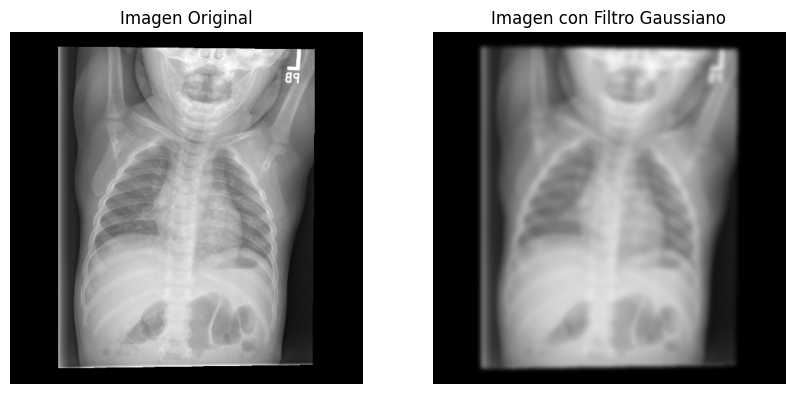

In [11]:
# FILTRO GAUSSIANO

def aplicar_filtro_gaussiano(imagen):
    imagen_filtrada = cv2.GaussianBlur(imagen, (19, 19), 0)
    return imagen_filtrada

imagen_filtrada = aplicar_filtro_gaussiano(img_front)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_front)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_filtrada)
plt.title('Imagen con Filtro Gaussiano')
plt.axis('off')

plt.show()

Suavizados paso alto y bajo

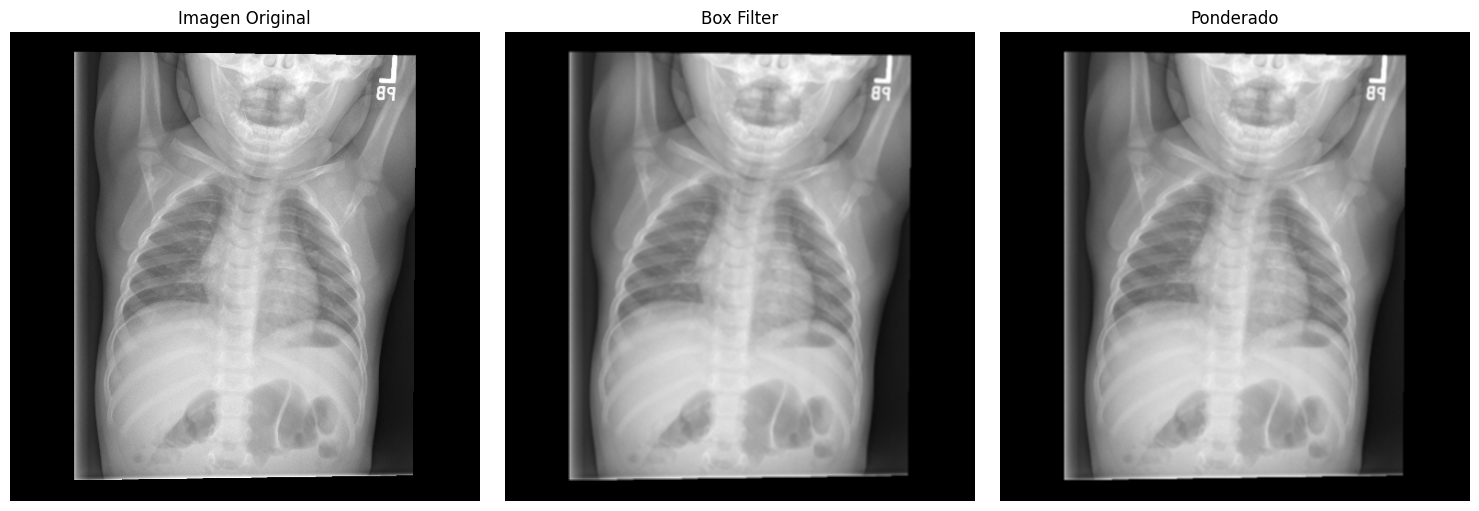

In [28]:
def box_filter(imagen):
    m=3
    n=3
    box_filter = np.ones((m, n), dtype=np.float32) / (m*n)
    filtered_image_box = cv2.filter2D(imagen, ddepth=-1, kernel=box_filter)
    return filtered_image_box

def pond_filter(imagen):
    pond_filter = np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ], dtype=np.float32) / 16
    filtered_image_pond = cv2.filter2D(imagen, ddepth=-1, kernel=pond_filter)
    return filtered_image_pond


box_image = box_filter(img_front)
pond_image = pond_filter(img_front)

# Mostrar resultados
plt.figure(figsize=(15, 5))

# Imagen original
plt.subplot(1, 3, 1)
plt.title("Imagen Original")
plt.imshow(img_front, cmap='gray')
plt.axis('off')

# Imagen con Box Filter
plt.subplot(1, 3, 2)
plt.title("Box Filter")
plt.imshow(box_image, cmap='gray')
plt.axis('off')

# Imagen con Gaussian-like Filter
plt.subplot(1, 3, 3)
plt.title("Ponderado")
plt.imshow(pond_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

OPERADORES

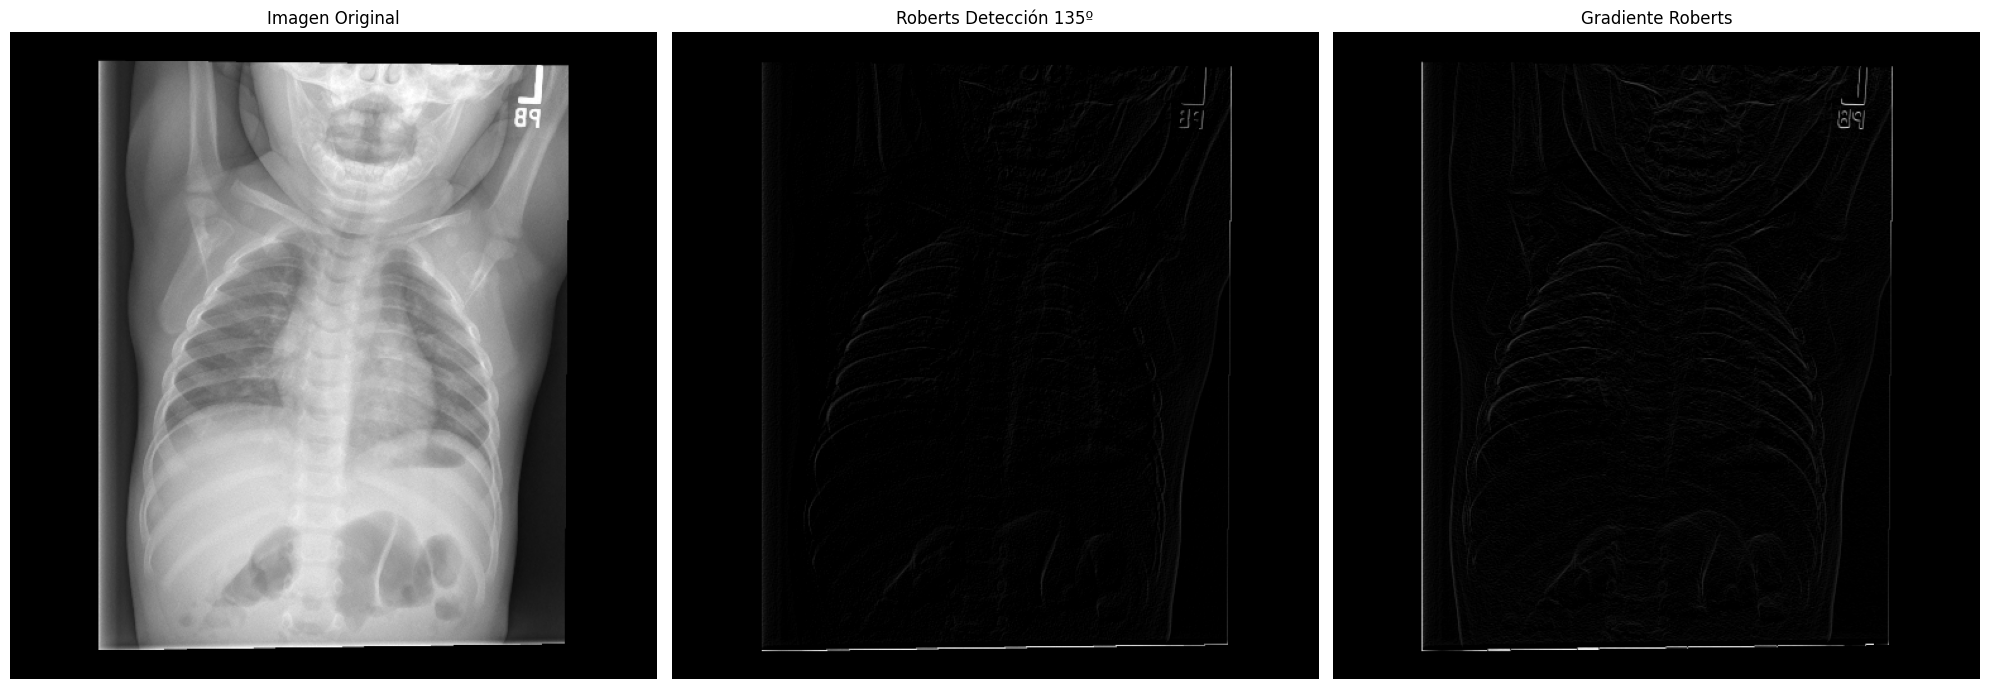

In [34]:
def roberts_135_filter(imagen):
    kernel_roberts_135 = np.array([[1,  0],
                                    [0, -1]])
    return cv2.filter2D(imagen, ddepth=-1, kernel=kernel_roberts_135)

def roberts_45_filter(imagen):
    kernel_roberts_45 = np.array([[0,  1],
                                   [-1, 0]])
    return cv2.filter2D(imagen, ddepth=-1, kernel=kernel_roberts_45)

def roberts_gradient(imagen):
    roberts_135 = roberts_135_filter(imagen)
    roberts_45 = roberts_45_filter(imagen)
    return cv2.convertScaleAbs(roberts_135 + roberts_45)

roberts_135_image = roberts_135_filter(img_front)
roberts_45_image = roberts_45_filter(img_front)
roberts_gradient_image = roberts_gradient(img_front)

plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.title("Imagen Original", fontsize=12)
plt.imshow(img_front, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Roberts Detección 135º", fontsize=12)
plt.imshow(roberts_135_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Gradiente Roberts", fontsize=12)
plt.imshow(roberts_gradient_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..576.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..765.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..765.0].


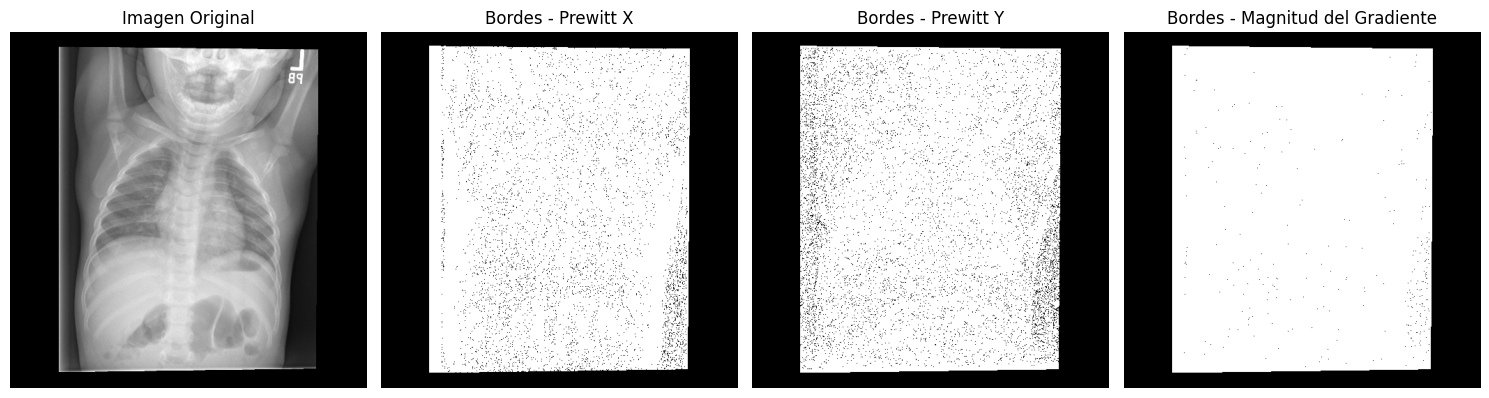

In [36]:
def prewitt_x_filter(imagen):
    kernel_x = np.array([[-1, 0, 1],
                         [-1, 0, 1],
                         [-1, 0, 1]], dtype=np.float32)
    return cv2.filter2D(imagen, cv2.CV_64F, kernel_x)

def prewitt_y_filter(imagen):
    kernel_y = np.array([[ 1,  1,  1],
                         [ 0,  0,  0],
                         [-1, -1, -1]], dtype=np.float32)
    return cv2.filter2D(imagen, cv2.CV_64F, kernel_y)

def prewitt_edge_detection(imagen):
    prewitt_x = prewitt_x_filter(imagen)
    prewitt_y = prewitt_y_filter(imagen)
    return np.sqrt(prewitt_x**2 + prewitt_y**2)  


prewitt_x_image = prewitt_x_filter(img_front)
prewitt_y_image = prewitt_y_filter(img_front)
prewitt_edge_image = prewitt_edge_detection(img_front)

plt.figure(figsize=(15, 8))

plt.subplot(1, 4, 1)
plt.title("Imagen Original")
plt.imshow(img_front, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Bordes - Prewitt X")
plt.imshow(np.abs(prewitt_x_image), cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Bordes - Prewitt Y")
plt.imshow(np.abs(prewitt_y_image), cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Bordes - Magnitud del Gradiente")
plt.imshow(np.abs(prewitt_edge_image), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def sobel_x_filter(imagen):
    return cv2.Sobel(imagen, cv2.CV_64F, 1, 0, ksize=3)

def sobel_y_filter(imagen):
    return cv2.Sobel(imagen, cv2.CV_64F, 0, 1, ksize=3)

def sobel_edge_detection(imagen):
    sobel_x = sobel_x_filter(imagen)
    sobel_y = sobel_y_filter(imagen)
    return np.sqrt(sobel_x**2 + sobel_y**2) 

img_front_normalized = cv2.normalize(img_front, None, 0, 255, cv2.NORM_MINMAX)

sobel_x_image = sobel_x_filter(img_front_normalized)
sobel_y_image = sobel_y_filter(img_front_normalized)
sobel_edge_image = sobel_edge_detection(img_front_normalized)

plt.figure(figsize=(15, 8))

plt.subplot(1, 4, 1)
plt.title("Imagen Original")
plt.imshow(img_front_normalized, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Bordes - Sobel X")
plt.imshow(np.abs(sobel_x_image), cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Bordes - Sobel Y")
plt.imshow(np.abs(sobel_y_image), cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Bordes - Magnitud del Gradiente")
plt.imshow(np.abs(sobel_edge_image), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

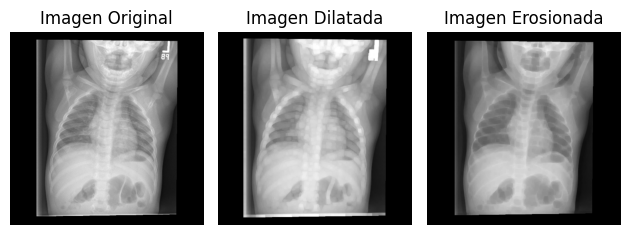

In [15]:
# EROSION Y DILATACION

# kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
kernel = np.ones((3, 3), np.uint8)


dilated = cv2.dilate(img_front, kernel, iterations=3)

eroded = cv2.erode(img_front, kernel, iterations=3)

plt.subplot(1, 3, 1)
plt.imshow(img_front, cmap='gray')
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(dilated, cmap='gray')
plt.title("Imagen Dilatada")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(eroded, cmap='gray')
plt.title("Imagen Erosionada")
plt.axis('off')

plt.tight_layout()
plt.show()

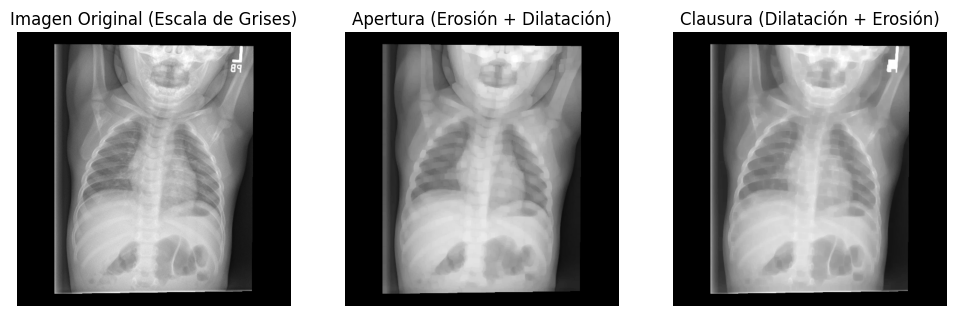

In [19]:
def erosion(imagen, kernel):
    return cv2.erode(imagen, kernel, iterations=3)

def dilatacion(imagen, kernel):
    return cv2.dilate(imagen, kernel, iterations=3)

def apertura(imagen, kernel):
    imagen_erosionada = erosion(imagen, kernel)
    imagen_apertura = dilatacion(imagen_erosionada, kernel)
    return imagen_apertura

def clausura(imagen, kernel):
    imagen_dilatada = dilatacion(imagen, kernel)
    imagen_clausura = erosion(imagen_dilatada, kernel)
    return imagen_clausura

imagen_gris = cv2.cvtColor(img_front, cv2.COLOR_RGB2GRAY)

tamano_kernel = 3
kernel = np.ones((tamano_kernel, tamano_kernel), np.uint8)

imagen_apertura_manual = apertura(imagen_gris, kernel)
imagen_clausura_manual = clausura(imagen_gris, kernel)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(imagen_gris, cmap='gray')
plt.title('Imagen Original (Escala de Grises)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imagen_apertura_manual, cmap='gray')
plt.title('Apertura (Erosión + Dilatación)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagen_clausura_manual, cmap='gray')
plt.title('Clausura (Dilatación + Erosión)')
plt.axis('off')

plt.show()

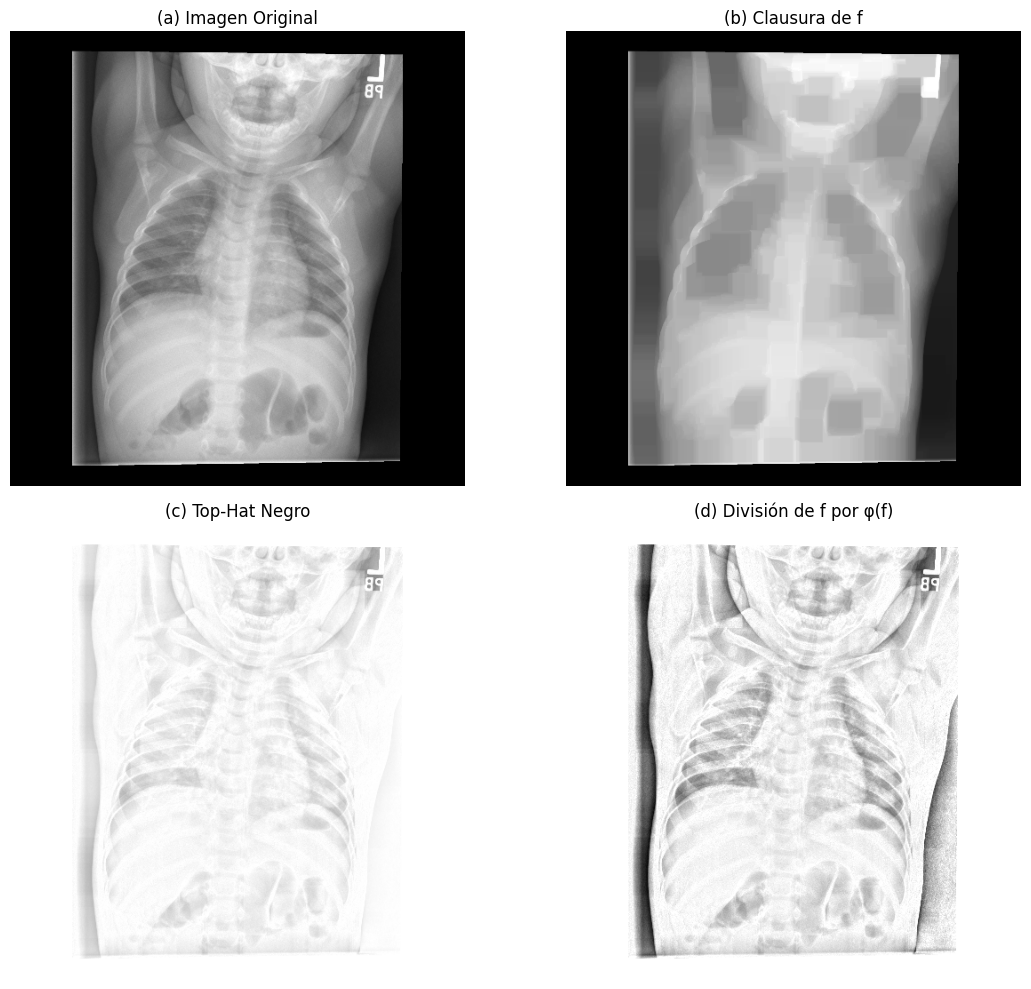

In [24]:

kernel_size = 25
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

original_image = img_front

closed_image = cv2.morphologyEx(original_image, cv2.MORPH_CLOSE, kernel)

black_tophat = 255-(closed_image - original_image)

epsilon = 1e-5
divided_image = cv2.divide(original_image.astype(np.float32) + epsilon,
                           closed_image.astype(np.float32) + epsilon)
divided_image = cv2.normalize(divided_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].imshow(original_image, cmap='gray')
axs[0, 0].set_title("(a) Imagen Original")
axs[0, 0].axis('off')

axs[0, 1].imshow(closed_image, cmap='gray')
axs[0, 1].set_title("(b) Clausura de f")
axs[0, 1].axis('off')

axs[1, 0].imshow(black_tophat, cmap='gray')
axs[1, 0].set_title("(c) Top-Hat Negro")
axs[1, 0].axis('off')

axs[1, 1].imshow(divided_image, cmap='gray')
axs[1, 1].set_title("(d) División de f por φ(f)")
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

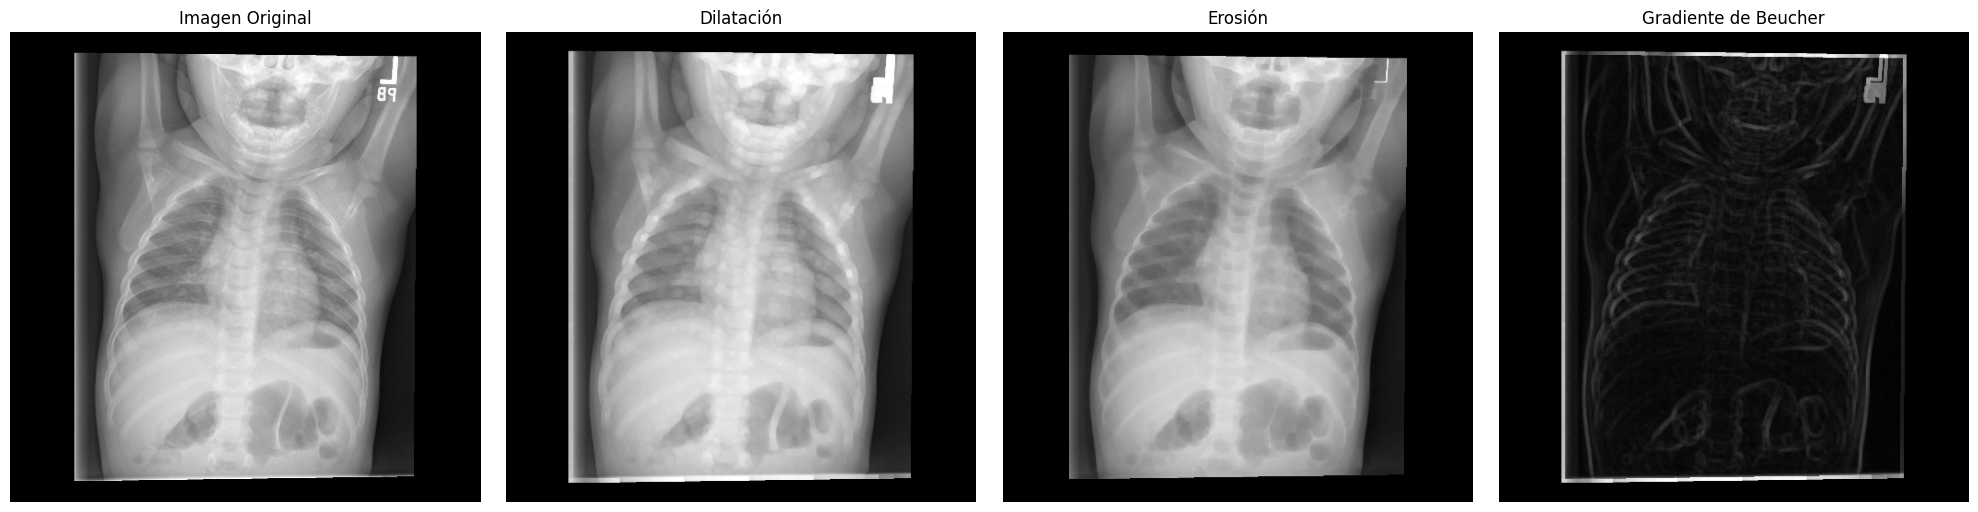

In [27]:
kernel = np.ones((5, 5), np.uint8)
image_dilated = cv2.dilate(img_front, kernel, iterations=1)

image_eroded = cv2.erode(img_front, kernel, iterations=1)

gradient_beucher = image_dilated - image_eroded
gradient_interno = img_front - image_eroded
gradient_externo = image_dilated - img_front

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.title("Imagen Original")
plt.imshow(img_front, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Dilatación")
plt.imshow(image_dilated, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Erosión")
plt.imshow(image_eroded, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Gradiente de Beucher")
plt.imshow(gradient_beucher, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()